<a href="https://colab.research.google.com/github/sukritimahajan35/Flipkart-Customer-Satisfaction-Analysis/blob/main/Customer_Satisfaction_towards_Flipkart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install Libraries

In [ ]:
!pip install pandas numpy matplotlib seaborn scipy statsmodels factor_analyzer wordcloud openpyxl -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Import Libraries

In [ ]:
import pandas as pd                         # Data handling
import numpy as np                          # Numerical operations
import matplotlib.pyplot as plt             # Plotting
import seaborn as sns                       # Visualization
from scipy import stats                     # Statistical tests
import statsmodels.api as sm                # Regression & QQ plot
from statsmodels.stats.outliers_influence import variance_inflation_factor
from factor_analyzer import FactorAnalyzer # Factor Analysis
from wordcloud import WordCloud             # Word cloud
from google.colab import files              # File upload

In [ ]:
# Set professional theme
sns.set(style="whitegrid")

Load Data

In [ ]:
print("Upload your dataset")
uploaded = files.upload()

file = list(uploaded.keys())[0]

# Load Without skipping first row first
df = pd.read_excel(file)

# Remove completely empty columns
df = df.loc[:, ~df.columns.isna()]

# Clean column names
df.columns = df.columns.astype(str).str.strip()

# If first column is timestamp, rename it
if df.columns[0].lower().startswith('timestamp'):
    df.rename(columns={df.columns[0]: 'Timestamp'}, inplace=True)

print("\nData Loaded Successfully")

Upload your dataset


Saving A Market Research on Customer Satisfaction towards Flipkart  (Responses).xlsx to A Market Research on Customer Satisfaction towards Flipkart  (Responses) (3).xlsx

Data Loaded Successfully


In [ ]:
display(df.head())

,Timestamp,Full Name,Age,Gender,Occupation,Monthly Income,How often do you shop on Flipkart?,How long have you been using Flipkart?,What type of products do you usually purchase from Flipkart?,Part 1 - Customer Satisfaction [Flipkart provides high quality products.],...,Part 2 - Customer Satisfaction [Discounts and offers are attractive.],Part 2 - Customer Satisfaction [Return process is simple and convenient.],Part 2 - Customer Satisfaction [Customer service responds promptly.],Part 2 - Customer Satisfaction [Customer complaints are handled effectively.],Customer Loyalty [I prefer Flipkart over other online shopping platforms.],Customer Loyalty [I will continue purchasing from Flipkart in the future.],Customer Loyalty [I would recommend Flipkart to my friends and family.],Customer Loyalty [I rarely switch to other platforms for similar products.],"Customer Loyalty [Even if prices increase slightly, I will continue using Flipkart.]",Customer Loyalty [I trust Flipkart as a reliable online shopping platform.]
0,2026-02-28 16:52:04.645,Mansi Wadhwa,18–25,Female,Student,Not Applicable (Student),Once in 3 months,1–3 years,"Electronics, Home Appliances, Beauty Products",5,...,4,5,4,5,5,5,4,5,4,5
1,2026-02-28 16:55:03.584,Madhav khanna,Below 18,Male,Student,Not Applicable (Student),Once a month,Less than 1 year,Clothing,4,...,4,4,4,4,4,4,4,4,4,4
2,2026-02-28 16:57:59.388,Nihar,18–25,Male,Private Employee,"₹50,000–₹1,00,000",Once in 3 months,More than 5 years,"Electronics, Beauty Products",3,...,3,2,2,2,3,3,3,2,2,3
3,2026-02-28 17:00:06.124,Mehak,18–25,Female,Student,"₹20,000–₹50,000",2–3 times a month,1–3 years,"Electronics, Clothing, Home Appliances, Beauty...",4,...,4,4,5,5,4,4,4,4,4,4
4,2026-02-28 17:19:57.736,Shubhra Gupta,18–25,Female,Student,"Below ₹20,000",Rarely,More than 5 years,"Clothing, Beauty Products",4,...,5,3,2,3,4,4,4,4,5,4


Data Preprocessing

In [ ]:
# Identify columns automatically
# Satisfaction columns (J to U) → index 9 to 20
sat_cols = df.iloc[:, 9:21]

# Loyalty columns (V to AA) → index 21 to 27
loy_cols = df.iloc[:, 21:27]

# Convert to numeric
sat_cols = sat_cols.apply(pd.to_numeric, errors='coerce')
loy_cols = loy_cols.apply(pd.to_numeric, errors='coerce')

# Create mean scores
df['Satisfaction'] = sat_cols.mean(axis=1)
df['Loyalty'] = loy_cols.mean(axis=1)

# Remove missing
df = df.dropna(subset=['Satisfaction','Loyalty'])

print("Preprocessing Done")

Preprocessing Done


Descriptive Analysis

In [ ]:
print("\nDescriptive Statistics Analysis")
print("="*70)

# Select variables
variables = ['Satisfaction', 'Loyalty']

# Basic descriptive statistics
desc = df[variables].describe().T

# Additional statistics
desc['Variance'] = df[variables].var()
desc['Skewness'] = df[variables].skew()
desc['Kurtosis'] = df[variables].kurt()

# Reorder columns professionally
desc = desc[['count','mean','std','Variance','min','25%','50%','75%','max','Skewness','Kurtosis']]

# Round values
desc = desc.round(3)

display(desc.style.background_gradient(cmap='Blues'))

# Interpretation
print("\nInterpretation")
print("="*70)

for var in variables:
    mean_val = df[var].mean()
    std_val = df[var].std()
    skew_val = df[var].skew()

    print(f"\n🔹 {var.upper()}")
    print(f"   • Mean = {mean_val:.3f}")
    print(f"   • Standard Deviation = {std_val:.3f}")

    if mean_val > 3:
        print("     → Mean is above neutral level (3), indicating positive perception.")
    elif mean_val == 3:
        print("     → Mean equals neutral level (3).")
    else:
        print("     → Mean is below neutral level, indicating dissatisfaction.")

    if skew_val > 0:
        print("     → Distribution is positively skewed (right tail).")
    elif skew_val < 0:
        print("     → Distribution is negatively skewed (left tail).")
    else:
        print("     → Distribution is symmetric.")


Descriptive Statistics Analysis


,count,mean,std,Variance,min,25%,50%,75%,max,Skewness,Kurtosis
Satisfaction,108.000000,4.380000,0.405000,0.164000,2.917000,4.167000,4.500000,4.667000,5.000000,-1.158000,1.265000
Loyalty,108.000000,4.182000,0.719000,0.516000,1.000000,4.000000,4.500000,4.667000,5.000000,-1.670000,3.122000



Interpretation

🔹 SATISFACTION
   • Mean = 4.380
   • Standard Deviation = 0.405
     → Mean is above neutral level (3), indicating positive perception.
     → Distribution is negatively skewed (left tail).

🔹 LOYALTY
   • Mean = 4.182
   • Standard Deviation = 0.719
     → Mean is above neutral level (3), indicating positive perception.
     → Distribution is negatively skewed (left tail).


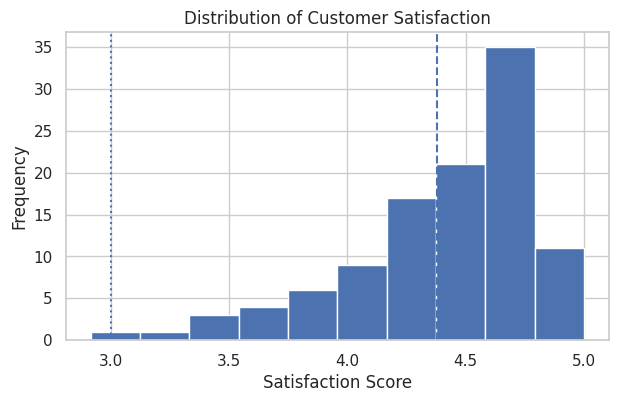

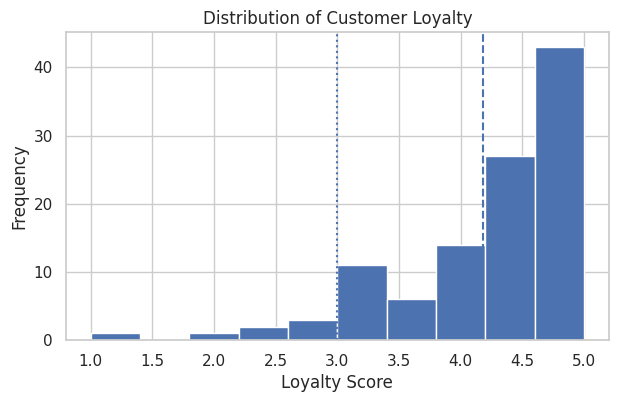

In [ ]:
# Satisfaction Plot
plt.figure(figsize=(7,4))
plt.hist(df['Satisfaction'], bins=10)
plt.axvline(df['Satisfaction'].mean(), linestyle='--')
plt.axvline(3, linestyle=':')
plt.title("Distribution of Customer Satisfaction")
plt.xlabel("Satisfaction Score")
plt.ylabel("Frequency")
plt.show()

# Loyalty Plot
plt.figure(figsize=(7,4))
plt.hist(df['Loyalty'], bins=10)
plt.axvline(df['Loyalty'].mean(), linestyle='--')
plt.axvline(3, linestyle=':')
plt.title("Distribution of Customer Loyalty")
plt.xlabel("Loyalty Score")
plt.ylabel("Frequency")
plt.show()

Normality Test

In [ ]:
print("\nNormality Test – Shapiro-Wilk")
print("="*60)

# Sample size
n = len(df['Satisfaction'])

# Run Shapiro test
stat, p = stats.shapiro(df['Satisfaction'])

# Additional distribution metrics
skew = df['Satisfaction'].skew()
kurt = df['Satisfaction'].kurt()

print(f"Sample Size (n)        : {n}")
print(f"Test Statistic (W)     : {stat:.4f}")
print(f"P-value                : {p:.6f}")
print(f"Skewness               : {skew:.3f}")
print(f"Kurtosis               : {kurt:.3f}")

print("\nHypotheses:")
print("H0: Data is normally distributed")
print("H1: Data is NOT normally distributed")

# Decision rule
alpha = 0.05
print("\nDecision (α = 0.05):")

if p > alpha:
    print("Fail to Reject H0 → Data follows Normal Distribution")
else:
    print("Reject H0 → Data does NOT follow Normal Distribution")

# Practical interpretation note
if n > 50:
    print("\nNote:")
    print("For large samples (n > 50), Shapiro test becomes very sensitive.")
    print("Minor deviations may lead to rejection even if distribution looks approximately normal.")


Normality Test – Shapiro-Wilk
Sample Size (n)        : 108
Test Statistic (W)     : 0.9087
P-value                : 0.000002
Skewness               : -1.158
Kurtosis               : 1.265

Hypotheses:
H0: Data is normally distributed
H1: Data is NOT normally distributed

Decision (α = 0.05):
Reject H0 → Data does NOT follow Normal Distribution

Note:
For large samples (n > 50), Shapiro test becomes very sensitive.
Minor deviations may lead to rejection even if distribution looks approximately normal.


<Figure size 600x600 with 0 Axes>

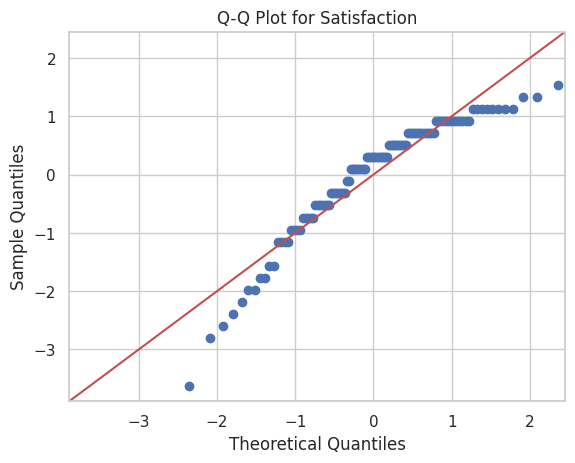

In [ ]:
# QQ Plot
plt.figure(figsize=(6,6))
sm.qqplot(df['Satisfaction'], line='45', fit=True)
plt.title("Q-Q Plot for Satisfaction")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)
plt.show()

Outlier Detection


Outlier Detection – IQR Method
Sample Size (n)        : 108
Q1 (25th percentile)   : 4.167
Q3 (75th percentile)   : 4.667
IQR                    : 0.500
Lower Bound            : 3.417
Upper Bound            : 5.417
Total Outliers         : 4
Lower Outliers         : 4
Upper Outliers         : 0
Outlier Percentage     : 3.70%

Outlier Observations:


,index,Satisfaction,Outlier Type
0,2,3.250000,Lower Outlier
1,11,3.416667,Lower Outlier
2,13,2.916667,Lower Outlier
3,106,3.333333,Lower Outlier


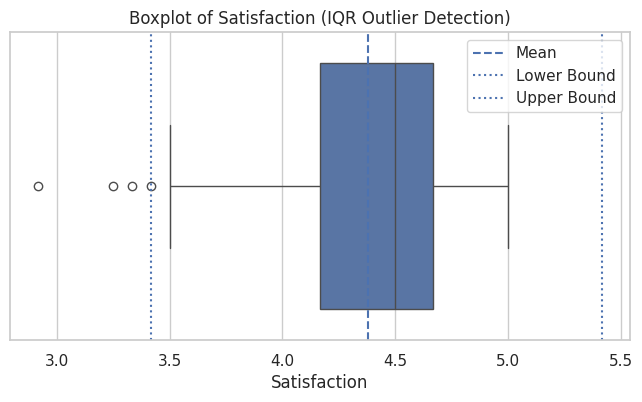


Conclusion:
4 outliers were detected (3.70% of total data).
These extreme values may influence statistical results and should be reviewed.


In [ ]:
print("\nOutlier Detection – IQR Method")
print("="*60)

# Basic stats
n = len(df['Satisfaction'])
mean_val = df['Satisfaction'].mean()

# Quartiles
Q1 = df['Satisfaction'].quantile(0.25)
Q3 = df['Satisfaction'].quantile(0.75)
IQR = Q3 - Q1

# Bounds
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['Satisfaction'] < lower) | (df['Satisfaction'] > upper)]

# Separate lower & upper
lower_out = df[df['Satisfaction'] < lower]
upper_out = df[df['Satisfaction'] > upper]

# Print results
print(f"Sample Size (n)        : {n}")
print(f"Q1 (25th percentile)   : {Q1:.3f}")
print(f"Q3 (75th percentile)   : {Q3:.3f}")
print(f"IQR                    : {IQR:.3f}")
print(f"Lower Bound            : {lower:.3f}")
print(f"Upper Bound            : {upper:.3f}")
print(f"Total Outliers         : {len(outliers)}")
print(f"Lower Outliers         : {len(lower_out)}")
print(f"Upper Outliers         : {len(upper_out)}")

# Outlier percentage
outlier_percent = (len(outliers) / n) * 100
print(f"Outlier Percentage     : {outlier_percent:.2f}%")

# Display Outlier Table
if len(outliers) > 0:
    print("\nOutlier Observations:")

    out_table = outliers[['Satisfaction']].copy()
    out_table['Outlier Type'] = out_table['Satisfaction'].apply(
        lambda x: "Lower Outlier" if x < lower else "Upper Outlier"
    )

    display(out_table.reset_index().style
            .background_gradient(subset=['Satisfaction'], cmap='Reds')
            .set_caption("Outliers Based on IQR Method"))
else:
    print("\nNo Outliers Detected")

# Boxplot Visualization
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Satisfaction'])

# Mean Line
plt.axvline(mean_val, linestyle='--', label='Mean')

# IQR Bounds
plt.axvline(lower, linestyle=':', label='Lower Bound')
plt.axvline(upper, linestyle=':', label='Upper Bound')

plt.title("Boxplot of Satisfaction (IQR Outlier Detection)")
plt.legend()
plt.show()

# Interpretation
if len(outliers) == 0:
    print("\nConclusion:")
    print("No significant outliers were detected using the IQR method.")
else:
    print("\nConclusion:")
    print(f"{len(outliers)} outliers were detected ({outlier_percent:.2f}% of total data).")
    print("These extreme values may influence statistical results and should be reviewed.")

Correlation Analysis (Pearson Correlation Test)


Correlation Analysis (Pearson Correlation Test)
H0: There is NO significant relationship between Satisfaction and Loyalty
H1: There IS a significant relationship between Satisfaction and Loyalty

Pearson Correlation Coefficient (r) = 0.5867
P-value = 0.000000
Relationship Strength: Moderate Positive
Reject H0 → Significant relationship exists


,Satisfaction,Loyalty
Satisfaction,1.000,0.587
Loyalty,0.587,1.000


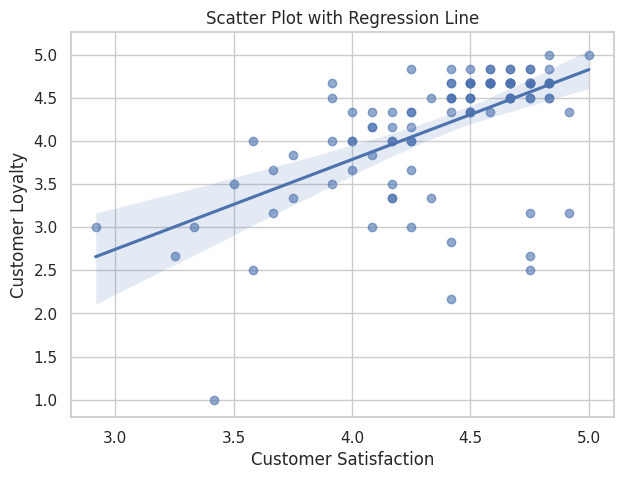


Interpretation:
There is a statistically significant moderate positive relationship between customer satisfaction and loyalty (r = 0.587, p < 0.05).


In [ ]:
print("\nCorrelation Analysis (Pearson Correlation Test)")
print("="*60)

# Hypothesis
print("H0: There is NO significant relationship between Satisfaction and Loyalty")
print("H1: There IS a significant relationship between Satisfaction and Loyalty\n")

# Pearson correlation test
r, p = stats.pearsonr(df['Satisfaction'], df['Loyalty'])

print(f"Pearson Correlation Coefficient (r) = {r:.4f}")
print(f"P-value = {p:.6f}")

# Strength interpretation
if abs(r) < 0.3:
    strength = "Weak"
elif abs(r) < 0.6:
    strength = "Moderate"
else:
    strength = "Strong"

direction = "Positive" if r > 0 else "Negative"

print(f"Relationship Strength: {strength} {direction}")

# Decision
if p < 0.05:
    print("Reject H0 → Significant relationship exists")
else:
    print("Fail to Reject H0 → No significant relationship")

# Correlation Matrix Table
corr_matrix = df[['Satisfaction','Loyalty']].corr()

display(
    corr_matrix.style
    .background_gradient(cmap='coolwarm')
    .format("{:.3f}")
    .set_caption("Correlation Matrix")
)

# Scatter Plot with Regression Line
plt.figure(figsize=(7,5))
sns.regplot(
    x='Satisfaction',
    y='Loyalty',
    data=df,
    ci=95,
    scatter_kws={'alpha':0.6}
)

plt.title("Scatter Plot with Regression Line")
plt.xlabel("Customer Satisfaction")
plt.ylabel("Customer Loyalty")
plt.show()

# Interpretation
print("\nInterpretation:")
if p < 0.05:
    print(f"There is a statistically significant {strength.lower()} {direction.lower()} "
          f"relationship between customer satisfaction and loyalty (r = {r:.3f}, p < 0.05).")
else:
    print("There is no statistically significant relationship between satisfaction and loyalty.")

One Sample t-Test


One Sample t-Test: Satisfaction vs Neutral Value (3)
H0: Mean Satisfaction = 3 (Neutral)
H1: Mean Satisfaction ≠ 3

Sample Statistics:
Sample Size (n)      = 108
Sample Mean          = 4.380
Standard Deviation   = 0.405

Test Results:
T-Statistic          = 35.426
P-value              = 0.000000
Effect Size (Cohen's d) = 3.409
95% Confidence Interval = (4.303, 4.458)

Decision: Reject H0
Conclusion: Mean Satisfaction is significantly different from neutral (3).


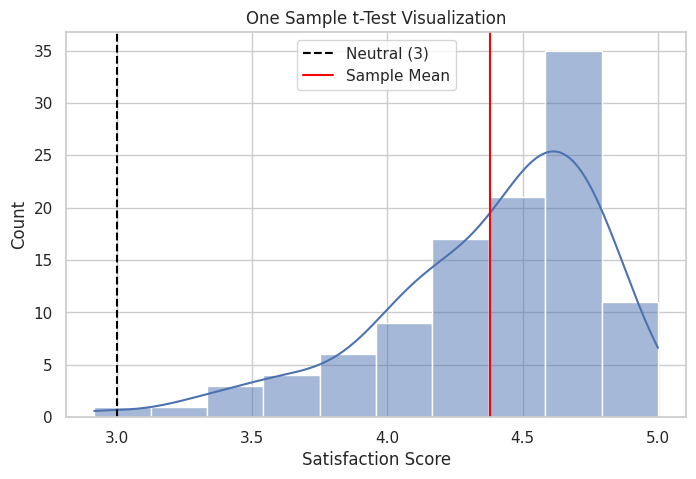


Interpretation :
The average satisfaction score (4.38) is significantly different from the neutral value of 3 (t = 35.43, p < 0.05). The effect size (d = 3.41) indicates a large effect.


In [ ]:
print("\nOne Sample t-Test: Satisfaction vs Neutral Value (3)")
print("="*65)

# Hypotheses
print("H0: Mean Satisfaction = 3 (Neutral)")
print("H1: Mean Satisfaction ≠ 3\n")

# Sample statistics
mean_val = df['Satisfaction'].mean()
std_val = df['Satisfaction'].std()
n = len(df)

print("Sample Statistics:")
print(f"Sample Size (n)      = {n}")
print(f"Sample Mean          = {mean_val:.3f}")
print(f"Standard Deviation   = {std_val:.3f}\n")

# One sample t-test
t, p = stats.ttest_1samp(df['Satisfaction'], 3)

# Effect size (Cohen's d)
cohen_d = (mean_val - 3) / std_val

# Confidence Interval
confidence = 0.95
dfree = n - 1
ci = stats.t.interval(confidence, dfree, loc=mean_val, scale=std_val/np.sqrt(n))

print("Test Results:")
print(f"T-Statistic          = {t:.3f}")
print(f"P-value              = {p:.6f}")
print(f"Effect Size (Cohen's d) = {cohen_d:.3f}")
print(f"95% Confidence Interval = ({ci[0]:.3f}, {ci[1]:.3f})\n")

# Decision
if p < 0.05:
    print("Decision: Reject H0")
    print("Conclusion: Mean Satisfaction is significantly different from neutral (3).")
else:
    print("Decision: Fail to Reject H0")
    print("Conclusion: No significant difference from neutral value.")

# Visualization
plt.figure(figsize=(8,5))
sns.histplot(df['Satisfaction'], kde=True)

plt.axvline(3, color='black', linestyle='--', label='Neutral (3)')
plt.axvline(mean_val, color='red', label='Sample Mean')

plt.title("One Sample t-Test Visualization")
plt.xlabel("Satisfaction Score")
plt.legend()
plt.show()

# Interpretation
print("\nInterpretation :")
if p < 0.05:
    print(f"The average satisfaction score ({mean_val:.2f}) is significantly different "
          f"from the neutral value of 3 (t = {t:.2f}, p < 0.05). "
          f"The effect size (d = {cohen_d:.2f}) indicates a "
          f"{'large' if abs(cohen_d)>0.8 else 'moderate' if abs(cohen_d)>0.5 else 'small'} effect.")
else:
    print("The mean satisfaction does not significantly differ from neutral.")

Independent t-Test


Independent t-Test: Gender Differences in Satisfaction

Group Statistics:
Male   → n = 50, Mean = 4.423, SD = 0.372
Female → n = 58, Mean = 4.343, SD = 0.431

Levene’s Test for Equality of Variances
P-value = 0.323621

Hypotheses:
H0: Mean Satisfaction (Male) = Mean Satisfaction (Female)
H1: Means are different

Test Results:
T-Statistic = 1.023
P-value     = 0.308532
Effect Size (Cohen's d) = 0.197

Decision: Fail to Reject H0
Conclusion: No statistically significant difference between genders.


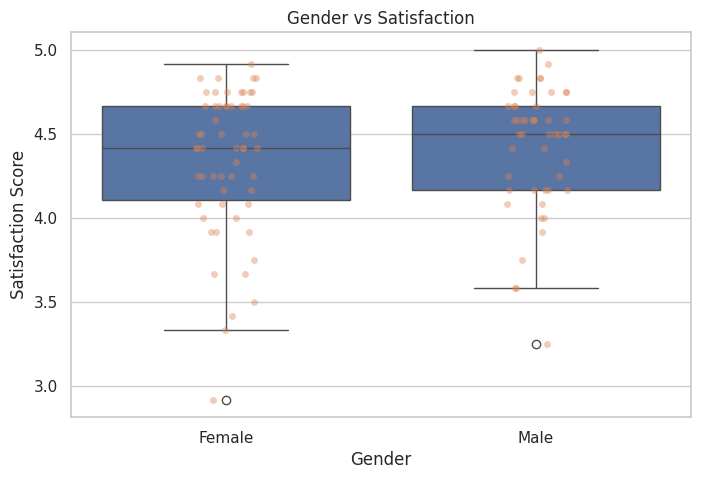


Interpretation:
The independent sample t-test showed no significant gender difference in satisfaction (t = 1.02, p > 0.05).


In [ ]:
if 'Gender' in df.columns:

    print("\nIndependent t-Test: Gender Differences in Satisfaction")
    print("="*75)

    # Clean Gender column (important)
    df['Gender'] = df['Gender'].astype(str).str.strip()

    male = df[df['Gender'] == 'Male']['Satisfaction']
    female = df[df['Gender'] == 'Female']['Satisfaction']

    # Group statistics
    print("\nGroup Statistics:")
    print(f"Male   → n = {len(male)}, Mean = {male.mean():.3f}, SD = {male.std():.3f}")
    print(f"Female → n = {len(female)}, Mean = {female.mean():.3f}, SD = {female.std():.3f}")

    # 1. Levene’s Test (Equality of Variance)
    lev_stat, lev_p = stats.levene(male, female)

    print("\nLevene’s Test for Equality of Variances")
    print(f"P-value = {lev_p:.6f}")

    equal_var = True if lev_p > 0.05 else False

    # 2. Independent t-test
    t2, p2 = stats.ttest_ind(male, female, equal_var=equal_var)

    print("\nHypotheses:")
    print("H0: Mean Satisfaction (Male) = Mean Satisfaction (Female)")
    print("H1: Means are different\n")

    print("Test Results:")
    print(f"T-Statistic = {t2:.3f}")
    print(f"P-value     = {p2:.6f}")

    # 3. Effect Size (Cohen's d)
    pooled_sd = np.sqrt(((len(male)-1)*male.std()**2 +
                         (len(female)-1)*female.std()**2) /
                         (len(male)+len(female)-2))

    cohen_d = (male.mean() - female.mean()) / pooled_sd
    print(f"Effect Size (Cohen's d) = {cohen_d:.3f}")

    # Decision
    if p2 < 0.05:
        print("\nDecision: Reject H0")
        print("Conclusion: There is a statistically significant difference between genders.")
    else:
        print("\nDecision: Fail to Reject H0")
        print("Conclusion: No statistically significant difference between genders.")

    # Visualization
    plt.figure(figsize=(8,5))
    sns.boxplot(x='Gender', y='Satisfaction', data=df)
    sns.stripplot(x='Gender', y='Satisfaction', data=df, alpha=0.4)

    plt.title("Gender vs Satisfaction")
    plt.xlabel("Gender")
    plt.ylabel("Satisfaction Score")
    plt.show()

    # Interpretation
    print("\nInterpretation:")
    if p2 < 0.05:
        print(f"A significant difference was found between male and female respondents "
              f"(t = {t2:.2f}, p < 0.05). The effect size (d = {abs(cohen_d):.2f}) "
              f"indicates a "
              f"{'large' if abs(cohen_d)>0.8 else 'moderate' if abs(cohen_d)>0.5 else 'small'} effect.")
    else:
        print(f"The independent sample t-test showed no significant gender difference "
              f"in satisfaction (t = {t2:.2f}, p > 0.05).")

One-Way Anova


One-Way Anova: Age vs Satisfaction

Group Statistics:
18–25 → n = 55, Mean = 4.289, SD = 0.449
26–35 → n = 21, Mean = 4.397, SD = 0.416
36–45 → n = 11, Mean = 4.561, SD = 0.201
Above 45 → n = 20, Mean = 4.533, SD = 0.268
Below 18 → n = 1, Mean = 4.000, SD = nan

Levene’s Test (Homogeneity of Variance)
P-value = 0.022121

Hypotheses:
H0: All age groups have equal mean satisfaction
H1: At least one group mean is different

ANOVA Results:
F-Statistic = 2.286
P-value     = 0.065058
Effect Size (Eta²) = 0.082

Decision: Fail to Reject H0
Conclusion: No significant difference among age groups.


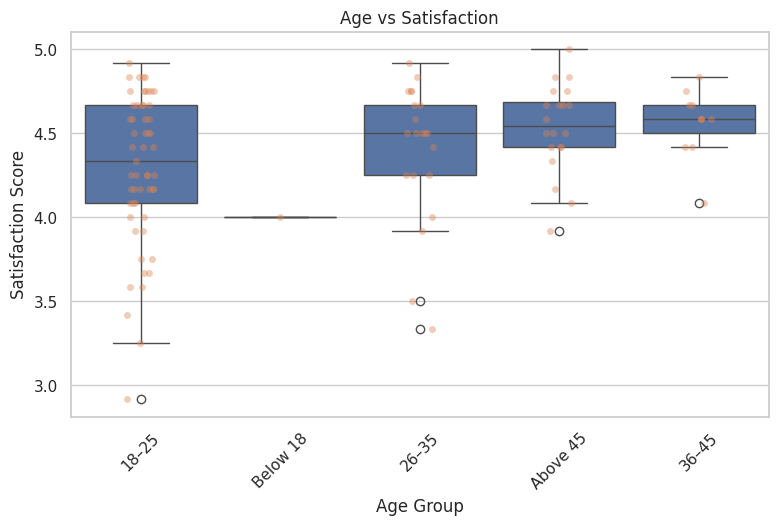


Interpretation:
The ANOVA indicated no significant difference in satisfaction across age groups (F = 2.29, p > 0.05).


In [ ]:
if 'Age' in df.columns:

    print("\nOne-Way Anova: Age vs Satisfaction")
    print("="*70)

    # Clean Age column
    df['Age'] = df['Age'].astype(str).str.strip()

    # 1. Group Statistics
    print("\nGroup Statistics:")
    age_groups = df.groupby('Age')['Satisfaction']
    for name, group in age_groups:
        print(f"{name} → n = {len(group)}, Mean = {group.mean():.3f}, SD = {group.std():.3f}")

    # 2. Levene’s Test (Homogeneity of Variance)
    grouped_data = [group for _, group in age_groups]
    lev_stat, lev_p = stats.levene(*grouped_data)

    print("\nLevene’s Test (Homogeneity of Variance)")
    print(f"P-value = {lev_p:.6f}")

    # 3. ANOVA Test
    f_stat, p_val = stats.f_oneway(*grouped_data)

    print("\nHypotheses:")
    print("H0: All age groups have equal mean satisfaction")
    print("H1: At least one group mean is different\n")

    print("ANOVA Results:")
    print(f"F-Statistic = {f_stat:.3f}")
    print(f"P-value     = {p_val:.6f}")

    # 4. Effect Size (Eta Squared)
    grand_mean = df['Satisfaction'].mean()
    ss_between = sum(len(group)*(group.mean()-grand_mean)**2 for group in grouped_data)
    ss_total = sum((df['Satisfaction']-grand_mean)**2)
    eta_sq = ss_between / ss_total

    print(f"Effect Size (Eta²) = {eta_sq:.3f}")

    # Decision
    if p_val < 0.05:
        print("\nDecision: Reject H0")
        print("Conclusion: Significant difference exists among age groups.")
    else:
        print("\nDecision: Fail to Reject H0")
        print("Conclusion: No significant difference among age groups.")

    # 5. Post-Hoc Test (Tukey) – Only if Significant
    if p_val < 0.05:
        print("\nPost-Hoc Analysis (Tukey HSD)")
        from statsmodels.stats.multicomp import pairwise_tukeyhsd

        tukey = pairwise_tukeyhsd(
            endog=df['Satisfaction'],
            groups=df['Age'],
            alpha=0.05
        )
        print(tukey)

    # Visualization
    plt.figure(figsize=(9,5))
    sns.boxplot(x='Age', y='Satisfaction', data=df)
    sns.stripplot(x='Age', y='Satisfaction', data=df, alpha=0.4)

    plt.title("Age vs Satisfaction")
    plt.xlabel("Age Group")
    plt.ylabel("Satisfaction Score")
    plt.xticks(rotation=45)
    plt.show()

    # Interpretation
    # -------------------------------
    print("\nInterpretation:")
    if p_val < 0.05:
        print(f"A one-way ANOVA revealed a significant effect of age on satisfaction "
              f"(F = {f_stat:.2f}, p < 0.05, η² = {eta_sq:.2f}).")
    else:
        print(f"The ANOVA indicated no significant difference in satisfaction "
              f"across age groups (F = {f_stat:.2f}, p > 0.05).")

Linear Regression Analysis


Simple Linear Regression: Satisfaction → Loyalty

Model Summary
R-squared        : 0.344
Adjusted R²      : 0.338
F-statistic      : 55.653
Prob (F-stat)    : 0.000000

Regression Equation
Loyalty = -0.379 + (1.041 × Satisfaction)

Coefficient Interpretation
Slope (β1)       : 1.041
P-value          : 0.000000
Satisfaction significantly predicts Loyalty.

Effect Size Interpretation
The model explains 34.4% of the variance in Loyalty.
Moderate explanatory power.

Full Statistical Table
                            OLS Regression Results                            
Dep. Variable:                Loyalty   R-squared:                       0.344
Model:                            OLS   Adj. R-squared:                  0.338
Method:                 Least Squares   F-statistic:                     55.65
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           2.50e-11
Time:                        19:23:22   Log-Likelihood:                -94.264
No. Observations:                 1

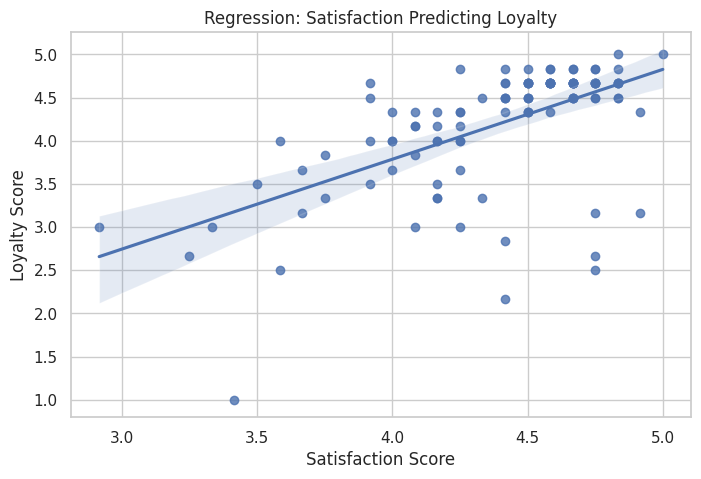


Interpretation
A significant positive relationship was found between satisfaction and loyalty (β = 1.04, p < 0.05). The model explains 34.4% of the variance in loyalty.


In [ ]:
print("\nSimple Linear Regression: Satisfaction → Loyalty")
print("="*75)

# 1. Define Variables
X = sm.add_constant(df['Satisfaction'])   # Add intercept
y = df['Loyalty']

# 2. Fit Model
model = sm.OLS(y, X).fit()

# 3. Extract Key Results
intercept = model.params['const']
slope = model.params['Satisfaction']
p_value = model.pvalues['Satisfaction']

# 4. Model Summary
# -------------------------------
print("\nModel Summary")
print(f"R-squared        : {model.rsquared:.3f}")
print(f"Adjusted R²      : {model.rsquared_adj:.3f}")
print(f"F-statistic      : {model.fvalue:.3f}")
print(f"Prob (F-stat)    : {model.f_pvalue:.6f}")

# 5. Regression Equation
print("\nRegression Equation")
print(f"Loyalty = {intercept:.3f} + ({slope:.3f} × Satisfaction)")

# 6. Coefficient Interpretation
print("\nCoefficient Interpretation")
print(f"Slope (β1)       : {slope:.3f}")
print(f"P-value          : {p_value:.6f}")

if p_value < 0.05:
    print("Satisfaction significantly predicts Loyalty.")
else:
    print("Satisfaction does NOT significantly predict Loyalty.")

# 7. Effect Size Interpretation
print("\nEffect Size Interpretation")
print(f"The model explains {model.rsquared*100:.1f}% of the variance in Loyalty.")

if model.rsquared >= 0.50:
    print("Strong explanatory power.")
elif model.rsquared >= 0.30:
    print("Moderate explanatory power.")
else:
    print("Weak explanatory power.")

# 8. Full Statistical Table
print("\nFull Statistical Table")
print(model.summary())

# 9. Visualization
plt.figure(figsize=(8,5))
sns.regplot(x='Satisfaction', y='Loyalty', data=df)

plt.title("Regression: Satisfaction Predicting Loyalty")
plt.xlabel("Satisfaction Score")
plt.ylabel("Loyalty Score")
plt.show()

# 10. Interpretation
print("\nInterpretation")

if p_value < 0.05:
    print(f"A significant positive relationship was found between satisfaction and loyalty "
          f"(β = {slope:.2f}, p < 0.05). "
          f"The model explains {model.rsquared*100:.1f}% of the variance in loyalty.")
else:
    print("The regression model was not statistically significant (p > 0.05).")

Non-Parametric Test 1: Mann-Whitney U Test (Gender → Satisfaction)


Mann-Whitney U Test: Gender → Satisfaction
Median (Male)   : 4.500
Median (Female) : 4.417

Hypothesis:
H0: No difference in Satisfaction between genders
H1: There is a difference

U Statistic = 1583.500
P-value     = 0.410856
Effect Size (r) = 0.079
No significant difference


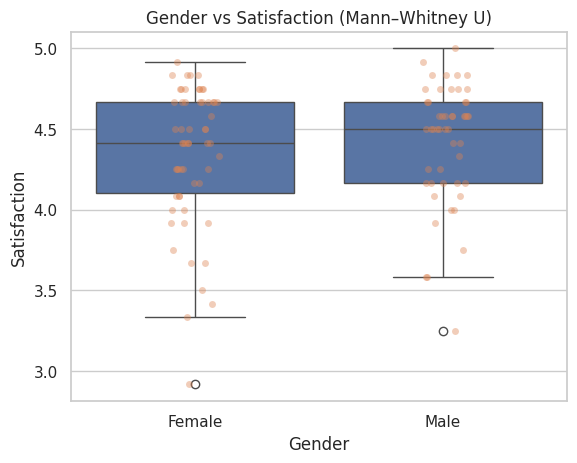

In [ ]:
from scipy.stats import mannwhitneyu
if 'Gender' in df.columns:

    print("\n" + "="*70)
    print("Mann-Whitney U Test: Gender → Satisfaction")
    print("="*70)

    male = df[df['Gender'] == 'Male']['Satisfaction'].dropna()
    female = df[df['Gender'] == 'Female']['Satisfaction'].dropna()

    # Medians
    print(f"Median (Male)   : {np.median(male):.3f}")
    print(f"Median (Female) : {np.median(female):.3f}")

    # Test
    stat, p = mannwhitneyu(male, female, alternative='two-sided')

    # Effect size (r)
    n1, n2 = len(male), len(female)
    z = (stat - (n1*n2/2)) / np.sqrt(n1*n2*(n1+n2+1)/12)
    r = abs(z) / np.sqrt(n1+n2)

    print("\nHypothesis:")
    print("H0: No difference in Satisfaction between genders")
    print("H1: There is a difference")

    print(f"\nU Statistic = {stat:.3f}")
    print(f"P-value     = {p:.6f}")
    print(f"Effect Size (r) = {r:.3f}")

    if p < 0.05:
        print("Significant difference between genders")
    else:
        print("No significant difference")

    # Better Visualization
    sns.boxplot(x='Gender', y='Satisfaction', data=df)
    sns.stripplot(x='Gender', y='Satisfaction', data=df, alpha=0.4)
    plt.title("Gender vs Satisfaction (Mann–Whitney U)")
    plt.show()

NON-PARAMETRIC TEST 2: Kruskal-Wallis Test (Age → Satisfaction)


Kruskal-Wallis TEST: Age → Satisfaction

Median Satisfaction by Age Group:
Age
18–25       4.333333
26–35       4.500000
36–45       4.583333
Above 45    4.541667
Below 18    4.000000
Name: Satisfaction, dtype: float64

Hypothesis:
H0: All age groups have equal satisfaction
H1: At least one age group differs

H Statistic = 7.316
P-value     = 0.120125
No significant difference across age groups


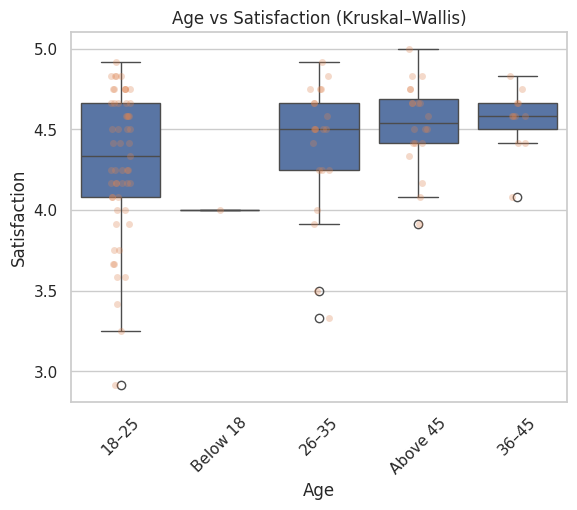

In [ ]:
from scipy.stats import kruskal
if 'Age' in df.columns:

    print("\n" + "="*70)
    print("Kruskal-Wallis TEST: Age → Satisfaction")
    print("="*70)

    grouped = df.groupby('Age')['Satisfaction']

    # Show medians
    medians = grouped.median()
    print("\nMedian Satisfaction by Age Group:")
    print(medians)

    groups = [group.dropna().values for name, group in grouped]

    stat, p = kruskal(*groups)

    print("\nHypothesis:")
    print("H0: All age groups have equal satisfaction")
    print("H1: At least one age group differs")

    print(f"\nH Statistic = {stat:.3f}")
    print(f"P-value     = {p:.6f}")

    if p < 0.05:
        print("Significant difference across age groups")
    else:
        print("No significant difference across age groups")

    # Better Visualization
    sns.boxplot(x='Age', y='Satisfaction', data=df)
    sns.stripplot(x='Age', y='Satisfaction', data=df, alpha=0.3)
    plt.xticks(rotation=45)
    plt.title("Age vs Satisfaction (Kruskal–Wallis)")
    plt.show()

Qualitative Analysis (Word Cloud + Text Insights)


Qualitative Analysis Started

Text Cleaning Completed


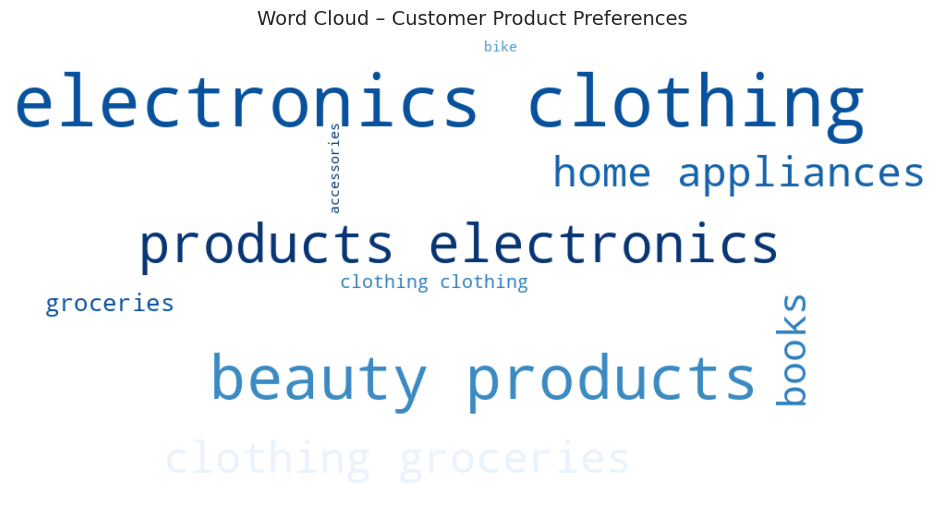


TOP 10 Keywords


,Word,Frequency
0,electronics,86
1,clothing,85
2,beauty,50
3,products,50
4,groceries,27
5,home,21
6,appliances,21
7,books,18
8,product,1
9,bike,1


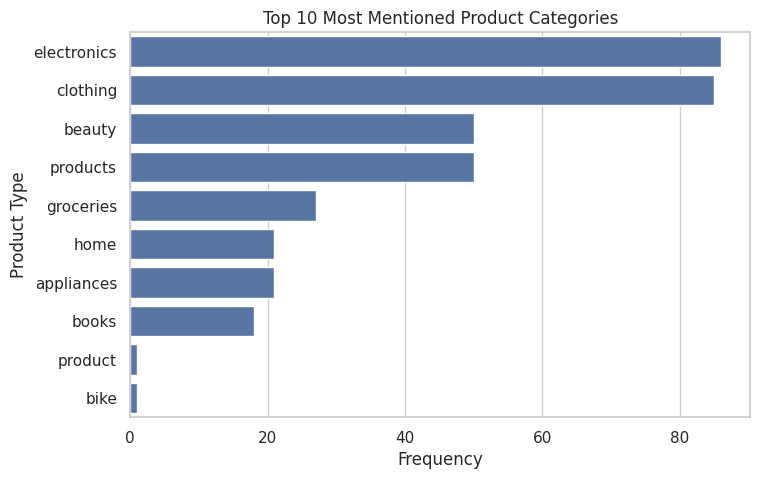


Interpretation:
Most frequently mentioned words represent popular product categories.
These insights help understand customer preferences and buying behavior.


In [ ]:
text_col = 'What type of products do you usually purchase from Flipkart?'

if text_col in df.columns:

    print("\nQualitative Analysis Started")

    # 1. Clean Text Data
    # Convert to string, remove missing values
    text_data = df[text_col].dropna().astype(str)

    # Combine all responses into one text
    full_text = ' '.join(text_data)

    # Convert to lowercase
    full_text = full_text.lower()

    # Remove unwanted characters
    import re
    full_text = re.sub(r'[^a-zA-Z\s]', '', full_text)

    # Remove common stopwords
    stopwords = set([
        'the','and','is','in','to','of','for','on','with','a','an','i','you',
        'it','this','that','are','was','as','at','be','by','or','from'
    ])

    words = [word for word in full_text.split() if word not in stopwords and len(word) > 2]

    cleaned_text = ' '.join(words)

    print("\nText Cleaning Completed")

    # 2. Word Cloud
    from wordcloud import WordCloud

    wc = WordCloud(
        width=1000,
        height=500,
        background_color='white',
        colormap='Blues',
        max_words=100,
        contour_width=1,
        contour_color='black'
    ).generate(cleaned_text)

    plt.figure(figsize=(12,6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title("Word Cloud – Customer Product Preferences", fontsize=14)
    plt.show()

    # 3. Top Word Frequency Table
    from collections import Counter

    word_counts = Counter(words)

    top_words = word_counts.most_common(10)

    freq_df = pd.DataFrame(top_words, columns=['Word', 'Frequency'])

    print("\nTOP 10 Keywords")
    display(freq_df.style.background_gradient(cmap='YlOrRd'))

    # 4. Bar Chart
    plt.figure(figsize=(8,5))
    sns.barplot(x='Frequency', y='Word', data=freq_df)
    plt.title("Top 10 Most Mentioned Product Categories")
    plt.xlabel("Frequency")
    plt.ylabel("Product Type")
    plt.show()

    # 5. Interpretation
    print("\nInterpretation:")
    print("Most frequently mentioned words represent popular product categories.")
    print("These insights help understand customer preferences and buying behavior.")

else:
    print("Column not found. Please check column name.")